In [24]:
import numpy as np
import yfinance as yf
import talib
import pandas as pd
import warnings
from datetime import date
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from models import StockPredictorNN, StockLSTM, HybridStockNet
from feature_engineering import FeatureEngineer

warnings.filterwarnings('ignore')

In [25]:
# READ S&P 500 TICKERS FROM TXT
def load_simple_ticker_list(filename='sp500_tickers.txt'):
    """Load tickers from simple text file (one per line)"""
    try:
        with open(filename, 'r') as f:
            tickers = [line.strip() for line in f.readlines() if line.strip()]
        return tickers
    except FileNotFoundError:
        print(f"❌ File {filename} not found.")
        return []

tickers = load_simple_ticker_list('sp500_tickers.txt')

In [26]:
# S&P 500 STOCK PROCESSING WITH LIMITS
import gc  # For garbage collection

# Configuration
sp500_tickers = tickers  # From loaded file
period = "10y"

# STOCK LIMIT CONFIGURATION
USE_FULL_DATASET = False  # Set to True when ready for full run
STOCK_LIMIT = 5          # Limit for testing (set to desired number)

# Apply stock limit
if USE_FULL_DATASET:
    processing_tickers = sp500_tickers
    print(f"🚀 FULL DATASET MODE: Processing all {len(processing_tickers)} S&P 500 stocks")
else:
    processing_tickers = sp500_tickers[:STOCK_LIMIT]
    print(f"🧪 TEST MODE: Processing first {len(processing_tickers)} stocks")

print("=" * 60)
print(f"📊 Dataset: S&P 500")
print(f"🎯 Stocks to process: {len(processing_tickers)}")
print("=" * 60)

all_data = []
total_tickers = len(processing_tickers)

# For progress tracking
successful_stocks = 0
failed_stocks = 0

# Instantiate the feature engineer
feature_engineer = FeatureEngineer()

for idx, ticker in enumerate(processing_tickers, 1):
    try:
        # Download data
        stock_data = yf.download(ticker, period=period, progress=False)
        
        if stock_data.empty:
            print(f"\r❌ [{idx}/{total_tickers}] {ticker}: No data available" + " " * 20)
            failed_stocks += 1
            continue

        # Generate features using the FeatureEngineer class
        features = feature_engineer.create_features(stock_data, ticker)
        
        # Add target and ticker
        features['Target'] = stock_data['Close'].shift(-1)  # Next day's close
        features['Ticker'] = ticker
        
        # Remove infinite and NaN values
        clean_data = features.dropna()
        
        if len(clean_data) > 0:
            all_data.append(clean_data)
            successful_stocks += 1
            if idx % 25 == 0 or idx == total_tickers:
                print(f"✅ [{idx}/{total_tickers}] {ticker}: {len(clean_data):,} samples")
        else:
            print(f"⚠️ [{idx}/{total_tickers}] {ticker}: No clean data after processing")
            failed_stocks += 1
        
        # GARBAGE COLLECTION
        if idx % 25 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            print(f"\r🧹 [{idx}/{total_tickers}] Memory cleanup completed" + " " * 30)
            
    except Exception as e:
        print(f"\r❌ [{idx}/{total_tickers}] {ticker}: Error - {str(e)}")
        failed_stocks += 1
        continue

# Final cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Clear progress line and show completion
print("=" * 60)
print(f"✅ Successful: {successful_stocks} stocks")
print(f"❌ Failed: {failed_stocks} stocks")
print(f"📊 Success rate: {successful_stocks/(successful_stocks+failed_stocks)*100:.1f}%" if (successful_stocks+failed_stocks) > 0 else "0.0%")
print("=" * 60)

# Combine all data
if all_data:
    ml_data = pd.concat(all_data, ignore_index=True)
    feature_count = len([col for col in ml_data.columns if col not in ['Target', 'Ticker']])
    
    print(f"📊 Total samples: {len(ml_data):,}")
    print(f"🔧 Features: {feature_count}")
    print(f"📈 Stocks: {len(ml_data['Ticker'].unique())}")
    print(f"💾 Memory: {ml_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"📅 Date range: {period}")
    
    # Show sample data
    sample_cols = ['Price_Change', 'RSI_14', 'MACD', 'ATR_14', 'Volume_Ratio_10', 'Target', 'Ticker']
    print(f"\n📋 SAMPLE DATA:")
    print(ml_data[sample_cols].head(3).round(4))
    
    print(f"\n✅ Ready for ML with {feature_count} features from {len(ml_data['Ticker'].unique())} stocks!")
    
else:
    print("\n❌ ERROR: No data processed successfully!")
    ml_data = pd.DataFrame()

🧪 TEST MODE: Processing first 5 stocks
📊 Dataset: S&P 500
🎯 Stocks to process: 5
✅ [5/5] ACN: 2,514 samples
✅ Successful: 5 stocks
❌ Failed: 0 stocks
📊 Success rate: 100.0%
📊 Total samples: 12,570
🔧 Features: 48
📈 Stocks: 5
💾 Memory: 5.4 MB
📅 Date range: 10y

📋 SAMPLE DATA:
   Price_Change   RSI_14   MACD  ATR_14  Volume_Ratio_10   Target Ticker
0       -0.0017  49.0229 -1.218  1.0568           0.8411  92.9927    MMM
1       -0.0017  49.0229 -1.218  1.0568           0.8411  92.8132    MMM
2       -0.0019  49.0229 -1.218  1.0568           0.8411  93.0227    MMM

✅ Ready for ML with 48 features from 5 stocks!


In [27]:
#Device Detection

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon GPU")
else:
    device = torch.device('cpu')
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4060


In [28]:
# DATA PREPARATION FOR PYTORCH
print("📊 PREPARING DATA FOR PYTORCH")
print("=" * 40)

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

def prepare_pytorch_data(ml_data, sequence_length=10, test_size=0.2, scale_target=True, log_transform_target=True): # 20% testing 80% training
    """
    Prepare data for PyTorch training
    
    Args:
        ml_data: Your dataset
        sequence_length: Number of days to look back (for LSTM)
        test_size: Fraction for testing
        scale_target: Whether to scale the target variable
        log_transform_target: Whether to transform data in log format
    """
    print(f"📋 Input data shape: {ml_data.shape}")
    
    # Separate features and target
    feature_cols = [col for col in ml_data.columns if col not in ['Target', 'Ticker']]
    features = ml_data[feature_cols]
    target = ml_data['Target']

    if log_transform_target:
            print("Applying log1p transformation to the target variable.")
            target = np.log1p(target) # log1p is log(1+x), safer for values near zero

    # --- Split data using train_test_split WITHOUT shuffling ---
    X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(
        features, 
        target, 
        test_size=test_size, 
        shuffle=False, # CRUCIAL: Do not shuffle time-series data
        random_state=42 # Ensures reproducibility, though not strictly needed with shuffle=False
    )

    # --- FIX: Fit scaler ONLY on training data ---
    feature_scaler = RobustScaler()
    X_train = feature_scaler.fit_transform(X_train_df)
    X_test = feature_scaler.transform(X_test_df) # Use transform, not fit_transform
    
    # Handle target scaling correctly
    y_train = y_train_df.values
    y_test = y_test_df.values
    if scale_target:
        target_scaler = RobustScaler()
        y_train = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        y_test = target_scaler.transform(y_test.reshape(-1, 1)).flatten()
    
    # Create sequences for LSTM from the ALREADY SPLIT and SCALED data
    def create_sequences(X, y, seq_len):
        X_seq, y_seq = [], []
        for i in range(seq_len, len(X)):
            X_seq.append(X[i-seq_len:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)
    
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, sequence_length)
    
    # Convert to PyTorch tensors
    data = {
        'regular': {
            'X_train': torch.FloatTensor(X_train).to(device),
            'X_test': torch.FloatTensor(X_test).to(device),
            'y_train': torch.FloatTensor(y_train).to(device),
            'y_test': torch.FloatTensor(y_test).to(device)
        },
        'sequence': {
            'X_train': torch.FloatTensor(X_train_seq).to(device) if len(X_train_seq) > 0 else None,
            'X_test': torch.FloatTensor(X_test_seq).to(device) if len(X_test_seq) > 0 else None,
            'y_train': torch.FloatTensor(y_train_seq).to(device) if len(y_train_seq) > 0 else None,
            'y_test': torch.FloatTensor(y_test_seq).to(device) if len(y_test_seq) > 0 else None
        },
        'scalers': {
            'feature_scaler': feature_scaler,
            'target_scaler': target_scaler
        },
        'log_transform_target': log_transform_target,
        'feature_names': feature_cols
    }
    
    print(f"✅ Regular data - Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"✅ Sequence data - Train: {X_train_seq.shape}, Test: {X_test_seq.shape}")
    print(f"📊 Features: {len(feature_cols)}")
    print(f"🎯 Target scaling: {'Yes' if scale_target else 'No'}")
    
    return data

# Prepare your FAANG data
if 'ml_data' in globals() and not ml_data.empty:
    pytorch_data = prepare_pytorch_data(ml_data, sequence_length=10, test_size=0.2, scale_target=True, log_transform_target=True)
    print(f"\n🚀 Data ready for GPU training!")
else:
    print("❌ ml_data not found. Run the FAANG data preparation cell first.")

print("=" * 40)

📊 PREPARING DATA FOR PYTORCH
📋 Input data shape: (12570, 50)
Applying log1p transformation to the target variable.
✅ Regular data - Train: (10056, 48), Test: (2514, 48)
✅ Sequence data - Train: (10046, 10, 48), Test: (2504, 10, 48)
📊 Features: 48
🎯 Target scaling: Yes

🚀 Data ready for GPU training!


In [34]:
# PYTORCH TRAINING FUNCTIONS AND EXECUTION
def train_pytorch_model(model, data, model_type='regular', epochs=50, batch_size=64, lr=0.001):
    """
    Train PyTorch model w/ GPU
    
    Args:
        model: PyTorch model
        data: Prepared data dictionary  
        model_type: 'regular' or 'sequence'
        epochs: Number of training epochs
        batch_size: Batch size for training
        lr: Learning rate
    """
    print(f"🏋️ Training {model.__class__.__name__} on {device}")
    
    # Get data (if sequence => LSTM)
    if model_type == 'sequence' and data['sequence']['X_train'] is not None:
        X_train, y_train = data['sequence']['X_train'], data['sequence']['y_train']
        X_test, y_test = data['sequence']['X_test'], data['sequence']['y_test']
    else:
        X_train, y_train = data['regular']['X_train'], data['regular']['y_train']
        X_test, y_test = data['regular']['X_test'], data['regular']['y_test']
    
    
    target_scaler = data['scalers']['target_scaler']
    log_transform_target = data.get('log_transform_target', False)
    
    print(f"📊 Training shape: {X_train.shape}")
    print(f"🎯 Test shape: {X_test.shape}")
    
    # Create data loaders
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)  # Removed verbose
    
    # Training metrics
    train_losses = []
    test_losses = []
    best_test_loss = float('inf')
    
    print(f"🏃 Starting training for {epochs} epochs...")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
    
        test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X).squeeze()
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
        
        # Calculate average losses
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        
        # Learning rate scheduling
        scheduler.step(avg_test_loss)
        
        # Save best model
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), f'best_{model.__class__.__name__.lower()}_model.pth')
        
        # Print progress
        if epoch % 20 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch:3d}: Train Loss: {avg_train_loss:.6f}, Test Loss: {avg_test_loss:.6f}')
    
    print(f"✅ Training completed! Best test loss: {best_test_loss:.6f}")
    
    # Final evaluation
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X).squeeze()
            predictions.extend(outputs.cpu().numpy().flatten().tolist())
            actuals.extend(batch_y.cpu().numpy().flatten().tolist())

    # --- NEW: REVERT TRANSFORMATIONS BEFORE CALCULATING METRICS ---
    predictions_np = np.array(predictions).reshape(-1, 1)
    actuals_np = np.array(actuals).reshape(-1, 1)

    # Step 1: Inverse scale the predictions and actuals
    if target_scaler:
        predictions_np = target_scaler.inverse_transform(predictions_np)
        actuals_np = target_scaler.inverse_transform(actuals_np)

    # Step 2: Inverse log transform
    if log_transform_target:
        predictions_np = np.expm1(predictions_np)
        actuals_np = np.expm1(actuals_np)
    
    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    mse = mean_squared_error(actuals_np, predictions_np)
    mae = mean_absolute_error(actuals_np, predictions_np)
    r2 = r2_score(actuals_np, predictions_np)
    
    print(f"📊 Final Metrics - MSE: {mse:.6f}, MAE: {mae:.6f}, R²: {r2:.4f}")
    
    return {
        'model': model,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'predictions': predictions_np.flatten().tolist(), # Return reverted predictions
        'actuals': actuals_np.flatten().tolist(),       # Return reverted actuals
        'metrics': {'mse': mse, 'mae': mae, 'r2': r2}
    }

In [30]:
print("🏗️ Creating Models:")
models = {
    'FeedForward': StockPredictorNN(feature_count).to(device),
    'LSTM': StockLSTM(feature_count).to(device),
    'Hybrid': HybridStockNet(feature_count).to(device)
}

for name, model in models.items():
    param_count = sum(p.numel() for p in model.parameters())
    print(f"  {name}: {param_count:,} parameters")

print(f"\n✅ All models loaded on {device}")
print("=" * 45)

🏗️ Creating Models:
  FeedForward: 54,657 parameters
  LSTM: 241,922 parameters
  Hybrid: 33,633 parameters

✅ All models loaded on cuda


In [31]:
# TRAIN ALL MODELS
print("🔥 TRAINING NEURAL NETWORKS")
print("=" * 50)

global_epochs = 50;
# Store results
results = {}

# 1. Train Feed-Forward Neural Network
print("\n1️⃣ TRAINING FEED-FORWARD NEURAL NETWORK")
print("-" * 45)
ff_model = StockPredictorNN(input_features=len(pytorch_data['feature_names'])).to(device)
results['FeedForward'] = train_pytorch_model(
    ff_model, pytorch_data, model_type='regular',
    epochs=global_epochs, batch_size=32, lr=0.001
)

# 2. Train LSTM Network
print("\n2️⃣ TRAINING LSTM NETWORK")
print("-" * 25)
lstm_model = StockLSTM(input_features=len(pytorch_data['feature_names'])).to(device)
if pytorch_data['sequence']['X_train'] is not None:
    results['LSTM'] = train_pytorch_model(
        lstm_model, pytorch_data, model_type='sequence',
        epochs=global_epochs, batch_size=16, lr=0.0005
    )
else:
    print("⚠️ Not enough data for sequence training")

# 3. Train Hybrid Network
print("\n3️⃣ TRAINING HYBRID CNN-LSTM NETWORK") 
print("-" * 35)
hybrid_model = HybridStockNet(input_features=len(pytorch_data['feature_names'])).to(device)
results['Hybrid'] = train_pytorch_model(
    hybrid_model, pytorch_data, model_type='regular',
    epochs=global_epochs, batch_size=32, lr=0.001
)

# Compare all models
print("\n🏆 MODEL COMPARISON RESULTS")
print("=" * 35)
print(f"{'Model':<12} {'MSE':<10} {'MAE':<10} {'R²':<8}")
print("-" * 40)

best_model = None
best_r2 = -float('inf')

for name, result in results.items():
    metrics = result['metrics']
    print(f"{name:<12} {metrics['mse']:<10.6f} {metrics['mae']:<10.6f} {metrics['r2']:<8.4f}")
    
    if metrics['r2'] > best_r2:
        best_r2 = metrics['r2']
        best_model = name

print("-" * 40)
print(f"🥇 Best Model: {best_model} (R² = {best_r2:.4f})")

print("\n✅ PyTorch GPU Training Complete!")
print("=" * 50)

🔥 TRAINING NEURAL NETWORKS

1️⃣ TRAINING FEED-FORWARD NEURAL NETWORK
---------------------------------------------
🏋️ Training StockPredictorNN on cuda
📊 Training shape: torch.Size([10056, 48])
🎯 Test shape: torch.Size([2514, 48])
🏃 Starting training for 50 epochs...
Epoch   0: Train Loss: 0.356876, Test Loss: 0.026014
Epoch  20: Train Loss: 0.025123, Test Loss: 0.031663
Epoch  40: Train Loss: 0.020358, Test Loss: 0.017350
Epoch  49: Train Loss: 0.019838, Test Loss: 0.028696
✅ Training completed! Best test loss: 0.007647
📊 Final Metrics - MSE: 2342.958928, MAE: 28.634227, R²: 0.7158

2️⃣ TRAINING LSTM NETWORK
-------------------------
🏋️ Training StockLSTM on cuda
📊 Training shape: torch.Size([10046, 10, 48])
🎯 Test shape: torch.Size([2504, 10, 48])
🏃 Starting training for 50 epochs...
Epoch   0: Train Loss: 0.041383, Test Loss: 0.082707
Epoch  20: Train Loss: 0.009779, Test Loss: 0.025489
Epoch  40: Train Loss: 0.009188, Test Loss: 0.077957
Epoch  49: Train Loss: 0.008955, Test Loss: 

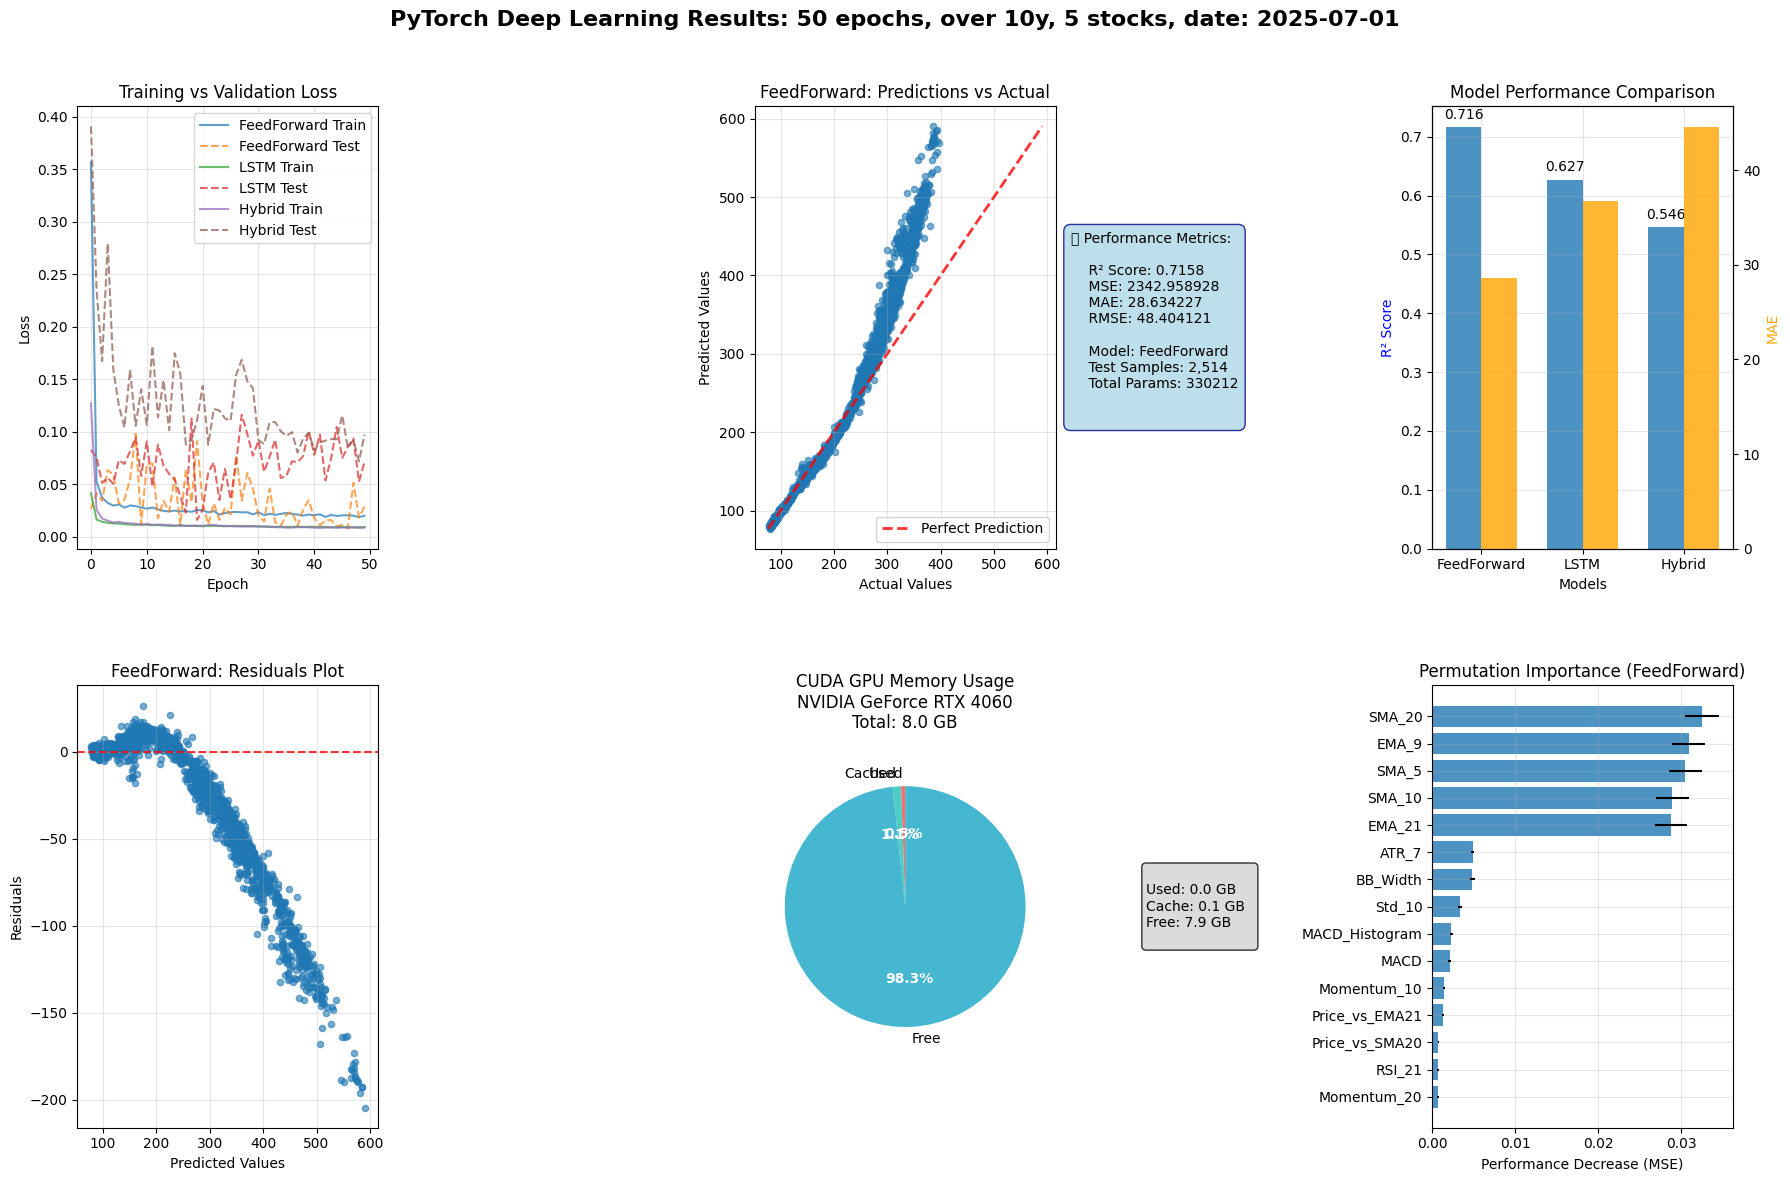

In [39]:
# PYTORCH RESULTS VISUALIZATION AND ANALYSIS

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Define models dictionary from existing model variables
models = {
    'FeedForward': ff_model,
    'LSTM': lstm_model,
    'Hybrid': hybrid_model
}

total_params = sum(sum(p.numel() for p in models[name].parameters()) for name in models.keys())

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'PyTorch Deep Learning Results: {global_epochs} epochs, over {period}, {STOCK_LIMIT} stocks, date: {date.today()}', fontsize=16, fontweight='bold')

# Plot 1: Training Loss Curves
ax1 = axes[0, 0]
for name, result in results.items():
    ax1.plot(result['train_losses'], label=f'{name} Train', alpha=0.7)
    ax1.plot(result['test_losses'], label=f'{name} Test', linestyle='--', alpha=0.7)
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Predictions vs Actual (Best Model)
ax2 = axes[0, 1]
if best_model in results:
    best_result = results[best_model]
    ax2.scatter(best_result['actuals'], best_result['predictions'], alpha=0.6, s=20)
    
    # Perfect prediction line
    min_val = min(min(best_result['actuals']), min(best_result['predictions']))
    max_val = max(max(best_result['actuals']), max(best_result['predictions']))
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2, label='Perfect Prediction')
    
    ax2.set_title(f'{best_model}: Predictions vs Actual')
    ax2.set_xlabel('Actual Values')
    ax2.set_ylabel('Predicted Values')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Add performance metrics text box
    best_metrics = best_result['metrics']
    metrics_text = f"""📊 Performance Metrics:

    R² Score: {best_metrics['r2']:.4f}
    MSE: {best_metrics['mse']:.6f}
    MAE: {best_metrics['mae']:.6f}
    RMSE: {np.sqrt(best_metrics['mse']):.6f}

    Model: {best_model}
    Test Samples: {len(best_result['predictions']):,}
    Total Params: {total_params}

    """
    
    ax2.text(1.05, 0.5, metrics_text, transform=ax2.transAxes, fontsize=10,
             verticalalignment='center', bbox=dict(boxstyle="round,pad=0.5", 
             facecolor="lightblue", alpha=0.8, edgecolor='darkblue'))

# Plot 3: Model Performance Comparison
ax3 = axes[0, 2]
model_names = list(results.keys())
r2_scores = [results[name]['metrics']['r2'] for name in model_names]
mae_scores = [results[name]['metrics']['mae'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax3.bar(x - width/2, r2_scores, width, label='R² Score', alpha=0.8)
ax3_twin = ax3.twinx()
bars2 = ax3_twin.bar(x + width/2, mae_scores, width, label='MAE', alpha=0.8, color='orange')

ax3.set_title('Model Performance Comparison')
ax3.set_xlabel('Models')
ax3.set_ylabel('R² Score', color='blue')
ax3_twin.set_ylabel('MAE', color='orange')
ax3.set_xticks(x)
ax3.set_xticklabels(model_names)
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars1, r2_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontsize=10)

# Plot 4: Residuals Analysis (Best Model)
ax4 = axes[1, 0]
if best_model in results:
    best_result = results[best_model]
    residuals = np.array(best_result['actuals']) - np.array(best_result['predictions'])
    ax4.scatter(best_result['predictions'], residuals, alpha=0.6, s=20)
    ax4.axhline(y=0, color='r', linestyle='--', alpha=0.8)
    ax4.set_title(f'{best_model}: Residuals Plot')
    ax4.set_xlabel('Predicted Values')
    ax4.set_ylabel('Residuals')
    ax4.grid(True, alpha=0.3)

# Plot 5: GPU/Device Memory Usage
ax5 = axes[1, 1]

# Get memory information based on device type
def get_memory_info():
    device_type = str(device)
    memory_info = {}
    
    if device_type.startswith('cuda'):
        # CUDA GPU memory
        memory_info['total'] = torch.cuda.get_device_properties(0).total_memory / 1024**3  # GB
        memory_info['allocated'] = torch.cuda.memory_allocated() / 1024**3  # GB
        memory_info['cached'] = torch.cuda.memory_reserved() / 1024**3  # GB
        memory_info['free'] = memory_info['total'] - memory_info['cached']
        memory_info['device_name'] = torch.cuda.get_device_name(0)
        memory_info['type'] = 'CUDA GPU'
    
    elif device_type.startswith('mps'):
        import psutil
        mem = psutil.virtual_memory()
        # MPS uses unified memory on Apple Silicon
        memory_info['total'] = mem.total / 1024**3  # GB
        memory_info['allocated'] = (mem.total - mem.available) / 1024**3  # GB
        memory_info['cached'] = mem.cached / 1024**3 if hasattr(mem, 'cached') else 0  # GB
        memory_info['free'] = mem.available / 1024**3  # GB
        memory_info['device_name'] = 'Apple Silicon GPU (Unified Memory)'
        memory_info['type'] = 'MPS (Metal)'
    else:
        import psutil
        mem = psutil.virtual_memory()
        #CPU fallback
        memory_info['total'] = mem.total / 1024**3  # GB
        memory_info['allocated'] = (mem.total - mem.available) / 1024**3  # GB
        memory_info['cached'] = 0
        memory_info['free'] = mem.available / 1024**3  # GB
        memory_info['device_name'] = 'CPU (System RAM)'
        memory_info['type'] = 'CPU'
    
    return memory_info

mem_info = get_memory_info()

# Create pie chart for memory usage
labels = ['Used', 'Cached', 'Free']
sizes = [mem_info['allocated'], mem_info['cached'], mem_info['free']]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

wedges, texts, autotexts = ax5.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                                   startangle=90)

# Beautify the pie chart
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax5.set_title(f'{mem_info["type"]} Memory Usage\n{mem_info["device_name"]}\nTotal: {mem_info["total"]:.1f} GB', 
              fontsize=12, pad=20)

# Add memory details as text
memory_text = f"""
Used: {mem_info['allocated']:.1f} GB
Cache: {mem_info['cached']:.1f} GB  
Free: {mem_info['free']:.1f} GB
"""

ax5.text(1.3, 0.5, memory_text, transform=ax5.transAxes, fontsize=10,
         verticalalignment='center', bbox=dict(boxstyle="round,pad=0.3", 
         facecolor="lightgray", alpha=0.8))
    

# Plot 6: Feature Importance (if available)
ax6 = axes[1, 2]
from sklearn.inspection import permutation_importance

if best_model in results and pytorch_data['feature_names']:
    
    # We need a scikit-learn compatible wrapper for the PyTorch model
    class SklearnPyTorchWrapper:
        def __init__(self, model, device):
            self.model = model
            self.device = device

        def fit(self, X, y=None):
            return self
        
        def predict(self, X):
            self.model.eval()
            X_tensor = torch.FloatTensor(X).to(self.device)
            with torch.no_grad():
                preds = self.model(X_tensor).cpu().numpy()
            return preds
        def score(self, X, y):
            y_pred = self.predict(X)
            return r2_score(y, y_pred)

    # Use the appropriate data (sequence or regular) for the best model
    model_type = 'sequence' if best_model in ['LSTM', 'Hybrid'] else 'regular'
    X_test_np = pytorch_data[model_type]['X_test'].cpu().numpy()
    y_test_np = pytorch_data[model_type]['y_test'].cpu().numpy()
    
    # Wrap the best performing model
    best_model_instance = results[best_model]['model']
    wrapped_model = SklearnPyTorchWrapper(best_model_instance, device)

    # Calculate permutation importance
    perm_importance = permutation_importance(
        wrapped_model, X_test_np, y_test_np, n_repeats=5, random_state=42, n_jobs=-1
    )
    
    # Get results
    sorted_idx = perm_importance.importances_mean.argsort()
    top_features = 15 # Show top 15
    
    ax6.barh(
        np.arange(top_features),
        perm_importance.importances_mean[sorted_idx][-top_features:],
        xerr=perm_importance.importances_std[sorted_idx][-top_features:],
        align='center', alpha=0.8
    )
    ax6.set_yticks(np.arange(top_features))
    ax6.set_yticklabels(np.array(pytorch_data['feature_names'])[sorted_idx][-top_features:])
    ax6.set_title(f'Permutation Importance ({best_model})')
    ax6.set_xlabel('Performance Decrease (MSE)')
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'Feature Importance\n(Not Available)', ha='center', va='center')


plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
plt.show()